<a href="https://colab.research.google.com/github/Azlan-Qaisrani/my-first/blob/main/LangGraph_Barista_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:

!pip install -qU 'langgraph==0.3.21' 'langchain-google-genai==2.1.2' 'langgraph-prebuilt==0.1.7'




In [11]:
import os
from google.colab import userdata
GOOGLE_API_KEY=userdata.get("google_api_key")


In [29]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages.ai import AIMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from collections.abc import Iterable
from random import randint
from langchain_core.messages.tool import ToolMessage
from pprint import pprint
from IPython.display import Image, display

In [30]:
class OrderState(TypedDict):
    """State representing the customer's order conversation."""
    messages: Annotated[list, add_messages]
    order: list[str]
    finished: bool

In [31]:
# Define System Instruction and Welcome Message ---
BARISTABOT_SYSINT = (
    "system",
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user) "
    "Always confirm_order with the user (double-check) before calling place_order. Calling confirm_order will "
    "display the order items to the user and returns their response to seeing the list. Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!"
    "\n\n"
    "If any of the tools are unavailable, you can break the fourth wall and tell the user that "
    "they have not implemented them yet and should keep reading to do so.",
)

WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

In [32]:
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
print("✅ State, Instructions, and LLM initialized.")

✅ State, Instructions, and LLM initialized.


In [33]:
#Tools Definitions ---

@tool
def get_menu() -> str:
    """Provide the latest up-to-date menu."""
    return """
    MENU:
    Coffee Drinks: Espresso, Americano, Cold Brew
    Coffee Drinks with Milk: Latte, Cappuccino, Cortado, Macchiato, Mocha, Flat White
    Tea Drinks: English Breakfast Tea, Green Tea, Earl Grey
    Tea Drinks with Milk: Chai Latte, Matcha Latte, London Fog
    Other Drinks: Steamer, Hot Chocolate
    Modifiers:
    Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free; Default option: whole
    Espresso shots: Single, Double, Triple, Quadruple; default: Double
    Caffeine: Decaf, Regular; default: Regular
    Hot-Iced: Hot, Iced; Default: Hot
    Sweeteners (option to add one or more): vanilla sweetener, hazelnut sweetener, caramel sauce, chocolate sauce, sugar free vanilla sweetener
    Special requests: any reasonable modification that does not involve items not on the menu, for example: 'extra hot', 'one pump', 'half caff', 'extra foam', etc.
    "dirty" means add a shot of espresso to a drink that doesn't usually have it, like "Dirty Chai Latte".
    "Regular milk" is the same as 'whole milk'.
    "Sweetened" means add some regular sugar, not a sweetener.
    Soy milk has run out of stock today, so soy is not available.
    """

In [34]:
@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Adds the specified drink to the customer's order, including any modifiers. Returns the updated order in progress."""
    pass

@tool
def confirm_order() -> str:
    """Asks the customer if the order is correct. Returns the user's free-text response."""
    pass

@tool
def get_order() -> str:
    """Returns the users order so far. One item per line."""
    pass

@tool
def clear_order():
    """Removes all items from the user's order."""
    pass

@tool
def place_order() -> int:
    """Sends the order to the barista for fulfillment. Returns the estimated number of minutes until the order is ready."""
    pass

In [35]:
#Node Functions ---

def human_node(state: OrderState) -> OrderState:
    """Display the last model message to the user, and receive the user's input."""
    last_msg = state["messages"][-1]
    print("Model:", last_msg.content)

    # Use a raw input prompt to get user input
    user_input = input("User: ")

    if user_input.lower() in {"q", "quit", "exit", "goodbye"}:
        state["finished"] = True

    return state | {"messages": [("user", user_input)]}

In [36]:
auto_tools = [get_menu]
order_tools = [add_to_order, confirm_order, get_order, clear_order, place_order]
all_tools = auto_tools + order_tools
llm_with_tools = llm.bind_tools(all_tools)

def chatbot_with_tools(state: OrderState) -> OrderState:
    """The chatbot with tools, handling the core conversation logic."""
    defaults = {"order": [], "finished": False}

    if state["messages"]:
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)

    return defaults | state | {"messages": [new_output]}

In [37]:
def order_node(state: OrderState) -> OrderState:
    """The ordering node. This is where the order state is manipulated based on tool calls."""
    tool_msg = state.get("messages", [])[-1]
    order = state.get("order", [])
    outbound_msgs = []
    order_placed = False

    for tool_call in tool_msg.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        response = None

        if tool_name == "add_to_order":
            modifiers = tool_args.get("modifiers", [])
            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"
            order.append(f'{tool_args["drink"]} ({modifier_str})')
            response = "\n".join(order)

        elif tool_name == "confirm_order":
            print("\n--- Your current order ---")
            if not order:
                print("  (no items)")
            for drink in order:
                print(f"  {drink}")
            print("--------------------------")
            response = input("Is this order correct? (Y/N or specific modifications) ")

        elif tool_name == "get_order":
            response = "\n".join(order) if order else "(no order)"

        elif tool_name == "clear_order":
            order.clear()
            response = "Order cleared."

        elif tool_name == "place_order":
            order_text = "\n".join(order)
            print("\n Sending Order to Kitchen..")
            print(order_text)
            order_placed = True
            response = randint(1, 5) # ETA in minutes

        else:
            raise NotImplementedError(f'Unknown tool call: {tool_name}')

        outbound_msgs.append(
            ToolMessage(
                content=str(response),
                name=tool_name,
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}

In [38]:
def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", END]:
    """Route to the chatbot, unless it looks like the user is exiting."""
    return END if state.get("finished", False) else "chatbot"

In [39]:
def maybe_route_to_tools(state: OrderState) -> str:
    """Route between chat, tool nodes, or END if order is placed."""
    if state.get("finished", False):
        return END

    msgs = state.get("messages", [])
    if not msgs:
        raise ValueError("No messages found.")

    msg = msgs[-1]

    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:

        ordering_tool_names = [t.name for t in order_tools]

        auto_tool_names = [t.name for t in auto_tools]

        if any(tool["name"] in ordering_tool_names for tool in msg.tool_calls):
            return "ordering"

        elif any(tool["name"] in auto_tool_names for tool in msg.tool_calls):
             return "tools"

    return "human"

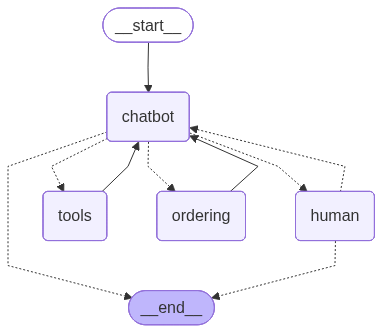

In [40]:
#Build the Graph
graph_builder = StateGraph(OrderState)

# Nodes
tool_node = ToolNode(auto_tools) # For get_menu
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("ordering", order_node)

# Edges
graph_builder.add_edge(START, "chatbot")
# Chatbot -> {ordering, tools, human, END}
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
# Human -> {chatbot, END}
graph_builder.add_conditional_edges("human", maybe_exit_human_node)
# Tools (both kinds) always route back to chat afterwards.
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("ordering", "chatbot")

# Compile
graph_with_order_tools = graph_builder.compile()
display(Image(graph_with_order_tools.get_graph().draw_mermaid_png()))

In [41]:

config = {"recursion_limit": 100}

print("=============================================")
print("  ☕ BARISTABOT IS LIVE! ☕")
print("=============================================")

# Invoke the graph with an empty initial state to start the conversation.
# Note: This will enter a loop and requires you to manually interact with the prompts.
try:
    final_state = graph_with_order_tools.invoke({"messages": []}, config)

    print("\n=============================================")
    print("  ✨ ORDER COMPLETE. FINAL STATE: ✨")
    print("=============================================")
    print("Final Order Items:")
    pprint(final_state.get("order", []))

except EOFError:
    # Handle the case where the user exits the input loop prematurely (e.g., in some Colab environments)
    print("\nAgent interaction finished or interrupted.")
except KeyboardInterrupt:
    print("\nAgent interaction stopped by user.")

# Things to try in the interactive loop:
# 1. Ask: "What drinks do you have?" (Triggers `get_menu` tool)
# 2. Order: "I want a hot mocha with oat milk." (Triggers `add_to_order`)
# 3. Order: "Also, a double espresso." (Triggers `add_to_order`)
# 4. Finish: "I'm done, place my order." (Triggers `confirm_order` then `place_order`)
# 5. Type 'q' to quit the chat at any time.

  ☕ BARISTABOT IS LIVE! ☕
Model: Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?
User: show me the menu
Model: Here is our menu:

Coffee Drinks: Espresso, Americano, Cold Brew
Coffee Drinks with Milk: Latte, Cappuccino, Cortado, Macchiato, Mocha, Flat White
Tea Drinks: English Breakfast Tea, Green Tea, Earl Grey
Tea Drinks with Milk: Chai Latte, Matcha Latte, London Fog
Other Drinks: Steamer, Hot Chocolate
Modifiers:
Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free; Default option: whole
Espresso shots: Single, Double, Triple, Quadruple; default: Double
Caffeine: Decaf, Regular; default: Regular
Hot-Iced: Hot, Iced; Default: Hot
Sweeteners (option to add one or more): vanilla sweetener, hazelnut sweetener, caramel sauce, chocolate sauce, sugar free vanilla sweetener
Special requests: any reasonable modification that does not involve items not on the menu, for example: 'extra hot', 'one pump', 'half caff', 'extra foam', etc.
"dirty" means add a shot of 